<a href="https://colab.research.google.com/github/HazemHassan2009/MNIST-Image-Classification/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Image Classification with ResNet50 Transfer Learning

This notebook demonstrates how to classify MNIST handwritten digits using a pre-trained ResNet50 model through transfer learning. We will load the MNIST dataset, preprocess the images to be compatible with ResNet50, fine-tune the model with custom classification layers, train it, and then evaluate its performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Set random seed for reproducibility
tf.random.set_seed(42)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("MNIST dataset loaded.")
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

MNIST dataset loaded.
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


## 1. Data Loading and Initial Inspection

We begin by loading the MNIST dataset, which consists of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is 28x28 pixels in grayscale.

In [ ]:
x_train, x_test = x_train / 255.0, x_test / 255.0

## 2. Data Preprocessing

To prepare the data for the ResNet50 model, several preprocessing steps are necessary:

1.  **Normalization**: Pixel values are normalized from the range [0, 255] to [0, 1] for better model performance.
2.  **Reshaping**: Grayscale MNIST images (28x28) are reshaped to (28x28x1). ResNet50 expects 3-channel input, so we duplicate the single channel to create an RGB-like image (28x28x3).
3.  **Resizing**: ResNet50 requires a minimum input size of 32x32 pixels, so the images are resized from 28x28 to 32x32.
4.  **ResNet-specific Preprocessing**: The `preprocess_input` function from `tf.keras.applications.resnet50` is applied to further prepare the pixel values according to how ResNet50 was originally trained (e.g., zero-centering, scaling).

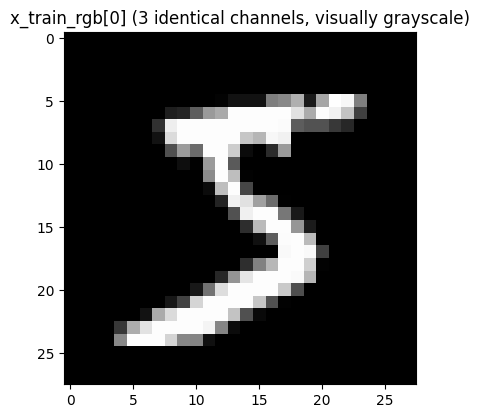

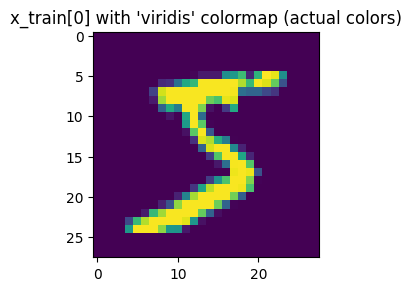

In [ ]:
import numpy as np
import matplotlib.cm as cm # Import colormap module


x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_train_rgb = np.repeat(x_train, 3, axis=-1)
x_test_rgb = np.repeat(x_test, 3, axis=-1)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(x_train_rgb[0])
plt.title("x_train_rgb[0] (3 identical channels, visually grayscale)")
plt.show()

# Create a colormapped version
sample_grayscale = x_train[0].squeeze()
colored_image_rgba = cm.viridis(sample_grayscale)
colored_image_rgb = colored_image_rgba[..., :3]

plt.subplot(1, 2, 2)
plt.imshow(colored_image_rgb)
plt.title("x_train[0] with 'viridis' colormap (actual colors)")
plt.show()

### Visualizing Preprocessing Steps

This section visualizes the transformation of a grayscale MNIST image into a 3-channel (RGB-like) image for ResNet50 compatibility. While `x_train_rgb` has three identical channels, effectively making it grayscale, a colormapped version is also shown to illustrate how a single-channel image can be represented with colors for visual distinction, though not directly used by the model in this way.

In [ ]:
# 1. Resize images to 32x32, as ResNet50 requires minimum 32x32 input
x_train_resized = tf.image.resize(x_train_rgb, (32, 32))
x_test_resized = tf.image.resize(x_test_rgb, (32, 32))

# 2. Preprocess input for ResNet50
x_train_processed = preprocess_input(x_train_resized)
x_test_processed = preprocess_input(x_test_resized)

## 3. Model Definition using Transfer Learning (ResNet50)

Transfer learning is employed here to leverage the powerful feature extraction capabilities of a pre-trained ResNet50 model.

1.  **Load Base Model**: We load the `ResNet50` model, pre-trained on the ImageNet dataset, but exclude its top classification layer (`include_top=False`) as we'll add our own. The `input_shape` is set to (32, 32, 3) to match our preprocessed MNIST images.
2.  **Freeze Base Layers**: To prevent the weights of the pre-trained ResNet50 layers from being updated during initial training, we set `layer.trainable = False` for all its layers. This keeps the learned ImageNet features intact.
3.  **Add Custom Classification Head**: New layers are added on top of the frozen ResNet50 base:
    *   `GlobalAveragePooling2D`: Reduces the spatial dimensions of the feature maps, producing a single feature vector for each image.
    *   `Dense` (Output Layer): A dense layer with 10 units (one for each MNIST digit) and `softmax` activation to output probability distributions over the classes.
4.  **Create and Compile Model**: The new model is constructed by combining the base ResNet50 input with our custom output layers. It's then compiled with the `adam` optimizer and `sparse_categorical_crossentropy` loss function, suitable for integer labels.

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model


# 3. Load the ResNet50 model without its top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 4. Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# 5. Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduce spatial dimensions
x = Dense(10, activation='softmax')(x) # Output layer for 10 MNIST classes

# 6. Create the new model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model (optimizer and loss can be adjusted later)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 4. Model Training

The compiled model is trained using the preprocessed training data (`x_train_processed`, `y_train`) and validated on the test data (`x_test_processed`, `y_test`). The `epochs` parameter controls the number of passes over the entire dataset, and `batch_size` determines the number of samples per gradient update. The training history provides insights into the model's performance during training.

In [ ]:
# Train the model
history = model.fit(
    x_train_processed,
    y_train,
    epochs=5, # You can adjust the number of epochs
    validation_data=(x_test_processed, y_test),
    batch_size=32
)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test_processed, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 291s 150ms/step - accuracy: 0.6999 - loss: 1.0484 - val_accuracy: 0.8002 - val_loss: 0.6803
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 311s 145ms/step - accuracy: 0.8203 - loss: 0.6115 - val_accuracy: 0.8416 - val_loss: 0.5245
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 271s 145ms/step - accuracy: 0.8515 - loss: 0.4996 - val_accuracy: 0.8645 - val_loss: 0.4498
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 269s 143ms/step - accuracy: 0.8685 - loss: 0.4385 - val_accuracy: 0.8753 - val_loss: 0.4050
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 264s 141ms/step - accuracy: 0.8809 - loss: 0.3984 - val_accuracy: 0.8849 - val_loss: 0.3747
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8849 - loss: 0.3747

Test Loss: 0.3747
Test Accuracy: 0.8849


## 5. Model Evaluation

After training, the model's performance is evaluated on the unseen test dataset.

*   **Test Loss and Accuracy**: These metrics provide an overall measure of how well the model generalizes.
*   **Classification Report**: This report offers a detailed breakdown of precision, recall, and F1-score for each class, giving insights into the model's performance per digit.
*   **Confusion Matrix**: A visual representation of the model's predictions versus the true labels. It helps identify which classes are being confused by the model.

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       980
           1       0.92      0.99      0.96      1135
           2       0.78      0.93      0.85      1032
           3       0.86      0.86      0.86      1010
           4       0.94      0.91      0.93       982
           5       0.89      0.83      0.86       892
           6       0.88      0.93      0.91       958
           7       0.94      0.86      0.90      1028
           8       0.95      0.64      0.77       974
           9       0.83      0.91      0.87      1009

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



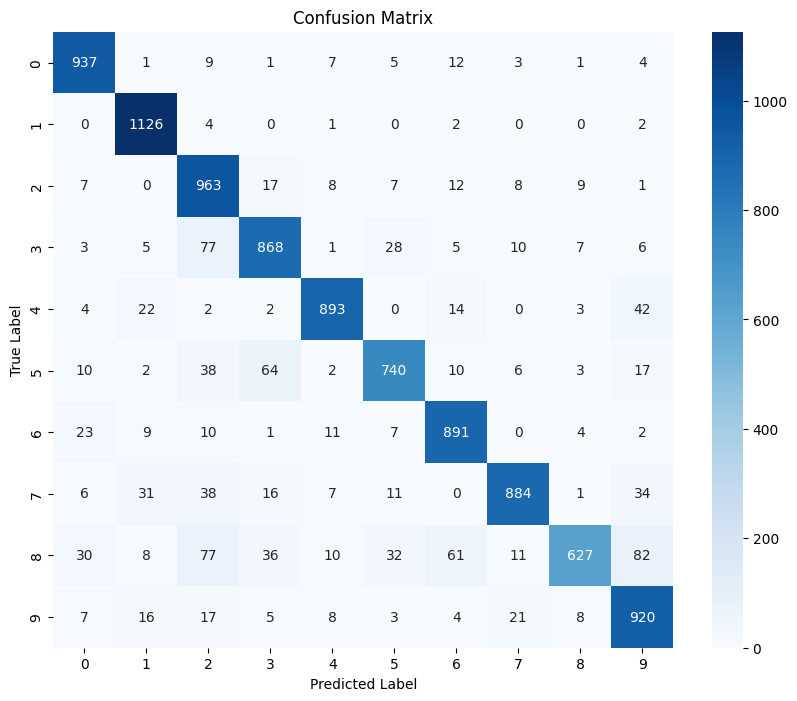

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns # for better visualization of confusion matrix

# Make predictions on the test set
y_pred_probs = model.predict(x_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
